---
title: "Matrix-exponential neural flow"
short_title: "02 · Matrix-exponential flow"
subtitle: "The linear special case of a continuous flow: dx/dt = Wx has the closed-form solution exp(Wt)x and the closed-form log-det t·tr(W) — no ODE solver, no Hutchinson, but only affine, so it Gaussianizes a Gaussian exactly and needs nonlinear partners for the rest"
description: >
  FFJORD pays for a free-form vector field with an ODE solve and a stochastic trace.
  Make the vector field linear, dx/dt = W x, and everything becomes closed-form: the
  flow map is the matrix exponential exp(Wt), and the log-det is exactly t·tr(W). This
  notebook builds gauss_flows' MatrixExponential, verifies the analytic log-det
  against autodiff, shows it Gaussianizes an anisotropic Gaussian exactly (the
  continuous-time cousin of Part 2's linear mixers), shows it cannot Gaussianize two
  moons (linear maps only do affine), and reads off the t-indexed family of
  distributions it encodes for free.
---

(sec-nb-ct-02)=
# 02 — Matrix-exponential neural flow

Notebooks [00](00_ffjord_2d.ipynb) and [01](01_hutchinson_trace.ipynb) paid two
prices for a *free-form* continuous flow: an ODE solve in both directions, and a
stochastic estimate of the log-det trace. Both prices vanish the moment the vector
field is **linear**. Take

$$
\frac{\mathrm{d}x_t}{\mathrm{d}t} = W x_t \;\;\Longrightarrow\;\; x_t = \exp(W t)\,x_0,
$$

the matrix exponential. The instantaneous change-of-variables trace is now constant
in $x$ — $\operatorname{tr}(\partial_x (Wx)) = \operatorname{tr}(W)$ — so the
log-det integral collapses to a closed form:

$$
\log\big|\det \partial x_T/\partial x_0\big| = \int_0^T \operatorname{tr}(W)\,\mathrm{d}t = T\,\operatorname{tr}(W).
$$

`gauss_flows.MatrixExponential` adds a time-gated bias, $y = \exp(W t)\,x + h(t)\,b$,
and is a **neural flow** {cite}`bilos2021neuralflows`, {cite}`kidger2021ndes`: the
closed-form solution of an ODE rather than something a solver integrates. It is the
continuous-time face of Part 2's **linear mixers** — a trainable, exactly-invertible
rotation-plus-scale with a free, analytic log-det. The catch is the flip side of the
gift: a linear map is *affine*, so on its own it can only Gaussianize a Gaussian.

**What you will see**

- A single layer morphing a ring as $t:0\to1$ — the identity at $t=0$ since $\exp(0)=I$.
- The log-det is exactly $t\,\operatorname{tr}(W)$ — checked against autodiff `slogdet`.
- It **Gaussianizes an anisotropic Gaussian** exactly (latent $\to\mathcal{N}(0,I)$).
- It **cannot** Gaussianize two moons — the affine ceiling, and why you compose it
  with nonlinear blocks (Parts 4-5) or use FFJORD.
- The $t$-indexed family of distributions a single trained model encodes for free.

In [1]:
import warnings

warnings.filterwarnings("ignore")

import equinox as eqx
import jax
import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt
import numpy as np
import optax
from flowjax.bijections import Chain
from flowjax.distributions import Normal, Transformed
from flowjax.train import fit_to_data
from scipy import stats
from sklearn.datasets import make_moons

from gauss_flows import MatrixExponential, TimeTanh, pack_time_control
from _style import DATA_COLOR, GAUSS_KW, LATENT_COLOR, SCATTER_KW, style_ax

jax.config.update("jax_enable_x64", True)

## 1. A single layer morphing a ring

Push the unit circle through $\exp(W t)\,\cdot + h(t)\,b$ for $t\in[0,1]$. At $t=0$
the map is the identity ($\exp(0)=I$, $h(0)=0$), and as $t$ grows it becomes a
rotated, scaled, shifted ellipse — a *continuum* of affine maps indexed by $t$.

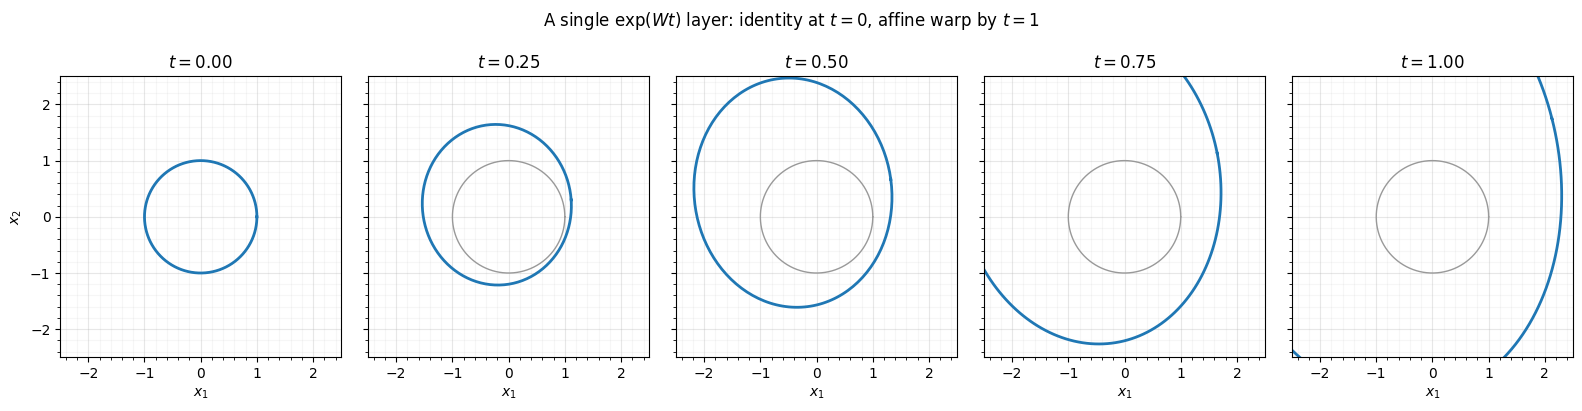

In [2]:
single = MatrixExponential(jr.key(0), shape=(2,), w_init_scale=0.6)
th = jnp.linspace(0.0, 2 * jnp.pi, 200)
ring = jnp.stack([jnp.cos(th), jnp.sin(th)], axis=-1)

times = jnp.linspace(0.0, 1.0, 5)
fig, axes = plt.subplots(1, 5, figsize=(16, 3.6), sharex=True, sharey=True)
for ax, t in zip(axes, times):
    pushed = jax.vmap(lambda p: single.transform_and_log_det(p, pack_time_control(float(t)))[0])(ring)
    ax.plot(np.asarray(ring[:, 0]), np.asarray(ring[:, 1]), color="0.6", lw=1.0)
    ax.plot(np.asarray(pushed[:, 0]), np.asarray(pushed[:, 1]), color=DATA_COLOR, lw=2.0)
    ax.set(title=rf"$t={float(t):.2f}$", xlabel="$x_1$", xlim=(-2.5, 2.5), ylim=(-2.5, 2.5))
    ax.set_aspect("equal")
    style_ax(ax)
axes[0].set_ylabel("$x_2$")
fig.suptitle(r"A single $\exp(Wt)$ layer: identity at $t=0$, affine warp by $t=1$", y=1.04)
fig.tight_layout()

## 2. The log-det is exactly $t\,\operatorname{tr}(W)$

This is the whole appeal: no trace integral to estimate, no solver — the log-det is
the analytic $t\,\operatorname{tr}(W)$, independent of the bias gate $h$ (a shift
never scales volume). We check it against an autodiff `slogdet` of the Jacobian on a
4-D layer with a learned time gate, across a range of query times.

max |closed-form - autodiff| over 21 times: 4.72e-16


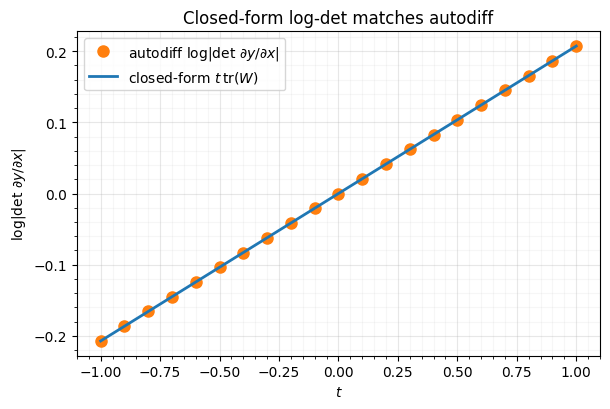

In [3]:
gate_key, w_key = jr.split(jr.key(1))
checked = MatrixExponential(w_key, shape=(4,), time_bias_net=TimeTanh(gate_key, embedding_dim=8),
                            w_init_scale=0.2)
x_eval = jr.normal(jr.key(2), (4,))
ts = jnp.linspace(-1.0, 1.0, 21)


def forward(x, t):
    return checked.transform_and_log_det(x, pack_time_control(t))[0]


closed = jax.vmap(lambda t: t * jnp.trace(checked.W))(ts)
ad = jax.vmap(lambda t: jnp.linalg.slogdet(jax.jacrev(forward)(x_eval, t))[1])(ts)

fig, ax = plt.subplots(figsize=(6.2, 4.2))
ax.plot(np.asarray(ts), np.asarray(ad), "o", color=LATENT_COLOR, ms=8,
        label=r"autodiff $\log|\det\,\partial y/\partial x|$")
ax.plot(np.asarray(ts), np.asarray(closed), "-", color=DATA_COLOR, lw=2,
        label=r"closed-form $t\,\mathrm{tr}(W)$")
ax.set(xlabel="$t$", ylabel=r"$\log|\det\,\partial y/\partial x|$",
       title="Closed-form log-det matches autodiff")
ax.legend()
style_ax(ax)
fig.tight_layout()
print(f"max |closed-form - autodiff| over 21 times: {float(jnp.max(jnp.abs(closed - ad))):.2e}")

Agreement to machine precision. The log-det never touches the Jacobian — it reads
$\operatorname{tr}(W)$ straight off the weight matrix.

## 3. Gaussianizing an anisotropic Gaussian — exactly

A linear flow is exactly the right tool when the data *is* Gaussian: whitening a
correlated, tilted Gaussian to $\mathcal{N}(0,I)$ is a linear map, and
`MatrixExponential` represents it with a closed-form log-det. We fit a short chain
(each block its own $W$, $b$, gate) to a tilted anisotropic Gaussian, querying the
time at $t=1$ so the chain acts as a fixed composition.

In [4]:
angle = jnp.pi / 6
R = jnp.array([[jnp.cos(angle), -jnp.sin(angle)], [jnp.sin(angle), jnp.cos(angle)]])
gauss = (jr.normal(jr.key(7), (2000, 2)) * jnp.array([1.7, 0.7])) @ R.T + jnp.array([0.5, -0.5])


def make_chain(key, n_layers=3):
    keys = jr.split(key, n_layers)
    return Chain([
        MatrixExponential(k, shape=(2,), time_bias_net=TimeTanh(jr.fold_in(k, 99), embedding_dim=8),
                          w_init_scale=0.3)
        for k in keys
    ])


def fit_chain(key, data, n_layers=3, max_epochs=250):
    # Closed-form flow => training is cheap; run a cosine-decayed schedule to
    # convergence (no early stopping) so the linear whitening actually settles.
    dist = Transformed(Normal(jnp.zeros(2)), make_chain(key, n_layers))
    t_one = jnp.broadcast_to(pack_time_control(1.0), (data.shape[0], 1))
    steps = -(-int(data.shape[0] * 0.9) // 256)
    sched = optax.cosine_decay_schedule(5e-3, decay_steps=max_epochs * steps, alpha=0.01)
    opt = optax.chain(optax.clip_by_global_norm(5.0), optax.adam(sched))
    trained, losses = fit_to_data(key, dist, (data, t_one), optimizer=opt,
                                  max_epochs=max_epochs, max_patience=max_epochs,
                                  batch_size=256, val_prop=0.1, show_progress=False)
    return trained, losses


gauss_dist, gauss_losses = fit_chain(jr.key(0), gauss)
print(f"anisotropic-Gaussian fit: stopped at {len(gauss_losses['train'])} epochs, "
      f"val NLL = {float(min(gauss_losses['val'])):.4f}")

anisotropic-Gaussian fit: stopped at 250 epochs, val NLL = 3.0454


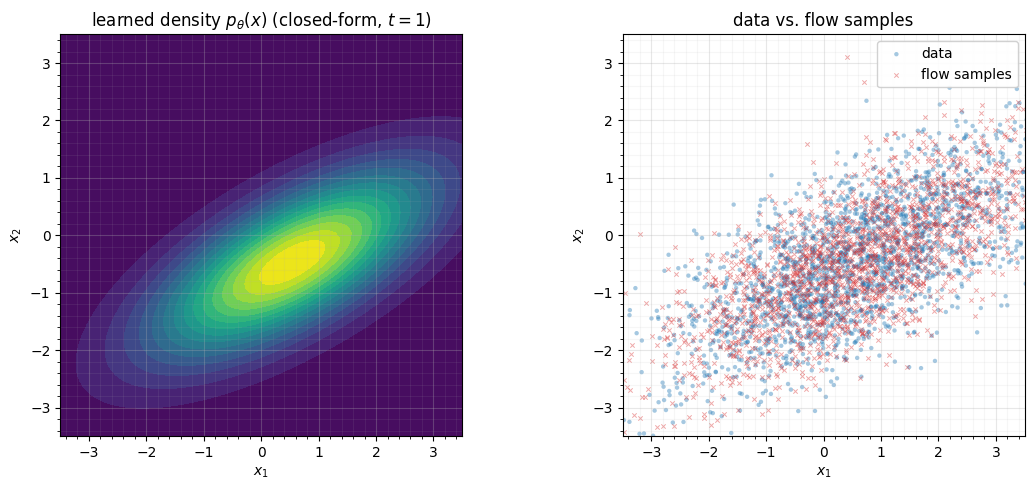

In [5]:
def gaussianize(chain, data):
    c1 = pack_time_control(1.0)
    return np.asarray(jax.vmap(lambda x: chain.inverse_and_log_det(x, c1)[0])(data))


def density_grid(dist, lim=3.5, n=80):
    xs = jnp.linspace(-lim, lim, n)
    gx, gy = jnp.meshgrid(xs, xs)
    pts = jnp.stack([gx.ravel(), gy.ravel()], -1)
    cond = jnp.broadcast_to(pack_time_control(1.0), (pts.shape[0], 1))
    lp = eqx.filter_jit(lambda p, c: jax.vmap(dist.log_prob)(p, c))(pts, cond)
    return gx, gy, jnp.exp(lp).reshape(n, n)


gx, gy, dens = density_grid(gauss_dist)
samp = gauss_dist.sample(jr.key(5), (2000,), condition=pack_time_control(1.0))

fig, (ax_d, ax_s) = plt.subplots(1, 2, figsize=(11.5, 5))
ax_d.contourf(np.asarray(gx), np.asarray(gy), np.asarray(dens), levels=20, cmap="viridis")
ax_d.set(title=r"learned density $p_\theta(x)$ (closed-form, $t=1$)", xlabel="$x_1$", ylabel="$x_2$")
ax_d.set_aspect("equal"); style_ax(ax_d)
ax_s.scatter(np.asarray(gauss[:, 0]), np.asarray(gauss[:, 1]), color=DATA_COLOR, label="data", **SCATTER_KW)
ax_s.scatter(np.asarray(samp[:, 0]), np.asarray(samp[:, 1]), color="tab:red", marker="x",
             s=10, alpha=0.4, linewidths=0.7, label="flow samples")
ax_s.set(title="data vs. flow samples", xlabel="$x_1$", ylabel="$x_2$", xlim=(-3.5, 3.5), ylim=(-3.5, 3.5))
ax_s.set_aspect("equal"); ax_s.legend(loc="upper right", framealpha=0.9); style_ax(ax_s)
fig.tight_layout()

Now the Gaussianization direction: push the data through the inverse map and check
the pushforward is standard normal.

Gaussianized moments (target 0, 1, 0, 0):
  z_1: mean=+0.021  std=1.083  skew=+0.031  exc-kurt=-0.122
  z_2: mean=-0.156  std=0.890  skew=-0.026  exc-kurt=-0.182


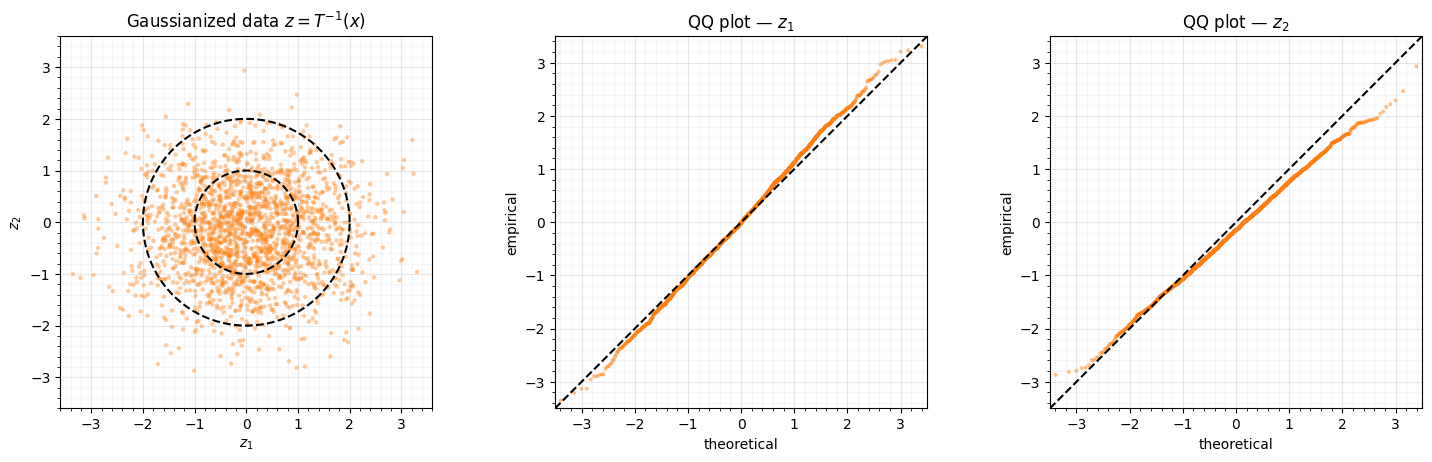

In [6]:
Z = gaussianize(gauss_dist.bijection, gauss)
fig, axes = plt.subplots(1, 3, figsize=(15, 4.6))
ax = axes[0]
ax.scatter(Z[:, 0], Z[:, 1], color=LATENT_COLOR, **SCATTER_KW)
for r in (1.0, 2.0):
    ax.plot(r * np.cos(th), r * np.sin(th), **GAUSS_KW)
ax.set(title=r"Gaussianized data $z=T^{-1}(x)$", xlabel="$z_1$", ylabel="$z_2$",
       xlim=(-3.6, 3.6), ylim=(-3.6, 3.6))
ax.set_aspect("equal"); style_ax(ax)
for j, ax in enumerate(axes[1:]):
    osm, osr = stats.probplot(Z[:, j], dist="norm", fit=False)
    ax.scatter(osm, osr, color=LATENT_COLOR, s=8, alpha=0.5, edgecolors="none")
    ax.plot([-3.5, 3.5], [-3.5, 3.5], **GAUSS_KW)
    ax.set(title=f"QQ plot — $z_{j + 1}$", xlabel="theoretical", ylabel="empirical",
           xlim=(-3.5, 3.5), ylim=(-3.5, 3.5))
    ax.set_aspect("equal"); style_ax(ax)
fig.tight_layout()
print("Gaussianized moments (target 0, 1, 0, 0):")
for j in range(2):
    z = Z[:, j]
    print(f"  z_{j + 1}: mean={z.mean():+.3f}  std={z.std():.3f}  "
          f"skew={stats.skew(z):+.3f}  exc-kurt={stats.kurtosis(z):+.3f}")

Clean: the latent fills the $\mathcal{N}(0,I)$ rings, the QQ plots sit on the
diagonal, the skew is ~0 and there are no residual modes — the map that whitens a
Gaussian *is* the affine family this flow spans, so the fit lands at the optimum (the
log-det being exact helps the optimiser get there). Contrast the next section, where
the target is not Gaussian.

## 4. The affine ceiling — two moons

Stacking matrix exponentials does *not* escape affine: a composition of linear maps
is linear. So the moment the data is genuinely non-Gaussian, a `MatrixExponential`
chain hits a wall. We fit the same chain to standardised two moons and look at the
Gaussianized latent — it keeps the bimodal crescent structure that no affine map can
remove.

two-moons latent excess-kurtosis: z_1=-0.408, z_2=-1.273  (non-zero => not Gaussianized)


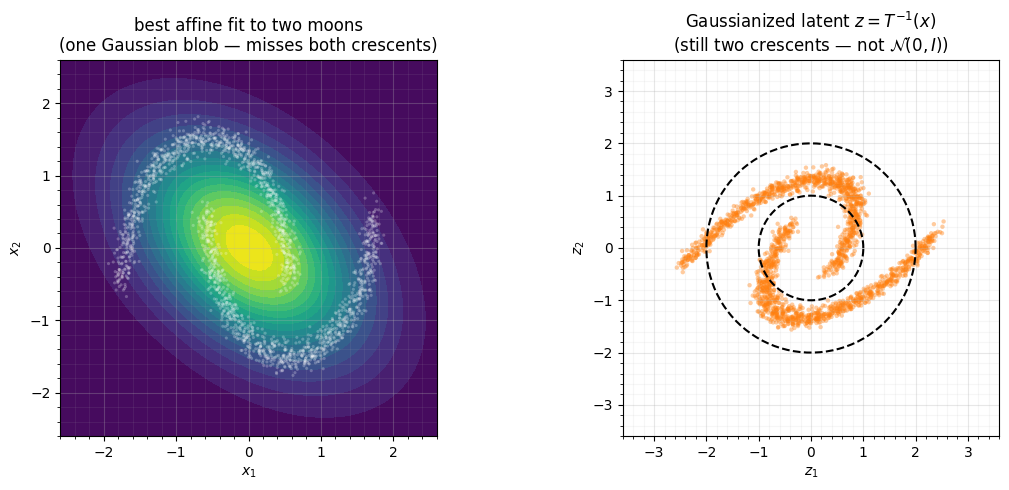

In [7]:
Xm = make_moons(n_samples=2000, noise=0.06, random_state=0)[0]
Xm = jnp.asarray((Xm - Xm.mean(0)) / Xm.std(0))
moons_dist, _ = fit_chain(jr.key(1), Xm)
gxm, gym, densm = density_grid(moons_dist, lim=2.6)
Zm = gaussianize(moons_dist.bijection, Xm)

fig, (ax_d, ax_z) = plt.subplots(1, 2, figsize=(11.5, 5))
ax_d.contourf(np.asarray(gxm), np.asarray(gym), np.asarray(densm), levels=20, cmap="viridis")
ax_d.scatter(np.asarray(Xm[:, 0]), np.asarray(Xm[:, 1]), s=5, alpha=0.25, color="white", edgecolors="none")
ax_d.set(title="best affine fit to two moons\n(one Gaussian blob — misses both crescents)",
         xlabel="$x_1$", ylabel="$x_2$")
ax_d.set_aspect("equal"); style_ax(ax_d)
ax_z.scatter(Zm[:, 0], Zm[:, 1], color=LATENT_COLOR, **SCATTER_KW)
for r in (1.0, 2.0):
    ax_z.plot(r * np.cos(th), r * np.sin(th), **GAUSS_KW)
ax_z.set(title=r"Gaussianized latent $z=T^{-1}(x)$" + "\n(still two crescents — not $\\mathcal{N}(0,I)$)",
         xlabel="$z_1$", ylabel="$z_2$", xlim=(-3.6, 3.6), ylim=(-3.6, 3.6))
ax_z.set_aspect("equal"); style_ax(ax_z)
fig.tight_layout()
print(f"two-moons latent excess-kurtosis: z_1={stats.kurtosis(Zm[:, 0]):+.3f}, "
      f"z_2={stats.kurtosis(Zm[:, 1]):+.3f}  (non-zero => not Gaussianized)")

The density is a single tilted blob and the latent is still two crescents: an affine
map cannot separate the modes. This is exactly why `MatrixExponential` earns its
keep as a **mixing block between nonlinear layers** — the continuous-time analogue
of a learned rotation in Part 2 — rather than as a stand-alone Gaussianizer. Slot a
coupling or mixture-CDF layer (Parts 4-5) between two matrix-exponential blocks, or
reach for FFJORD, and the modes come apart.

## 5. The $t$-indexed family, for free

Because the bijection carries an explicit time, training at $t=1$ hands us the whole
one-parameter family $p_t = (\exp(W_L t)\circ\cdots\circ\exp(W_1 t))_\#\,
\mathcal{N}(0,I)$ — a smooth, *exact* interpolation from the base Gaussian at $t=0$
to the fitted target at $t=1$, queryable at any $t$ with no retraining and no solver.

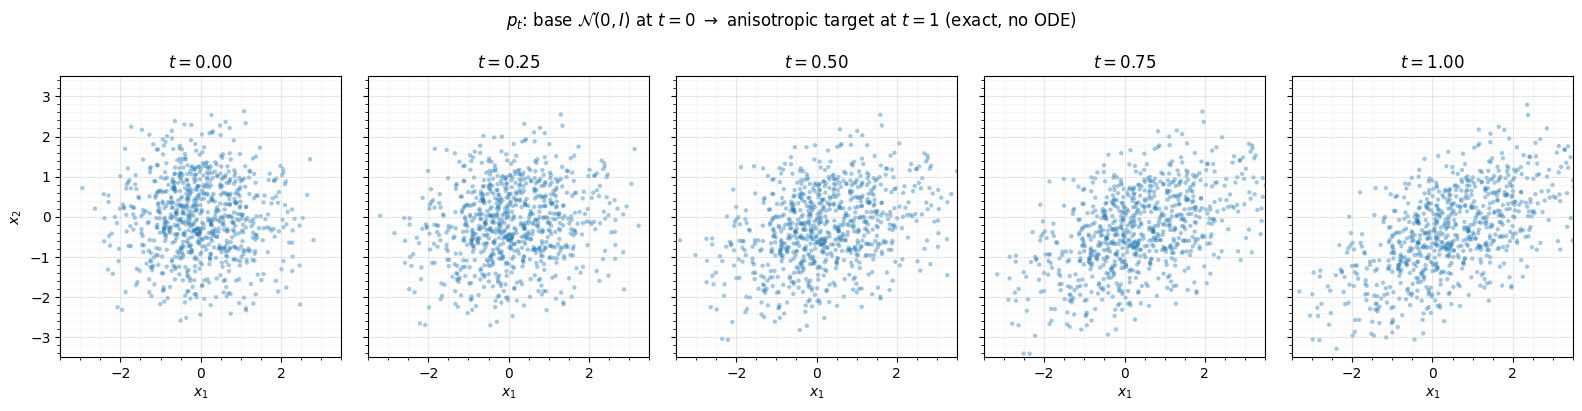

In [8]:
chain = gauss_dist.bijection
base = jr.normal(jr.key(17), (800, 2))
sweep = jnp.linspace(0.0, 1.0, 5)
fig, axes = plt.subplots(1, 5, figsize=(16, 3.6), sharex=True, sharey=True)
for ax, t in zip(axes, sweep):
    ct = pack_time_control(float(t))
    pushed = jax.vmap(lambda z: chain.transform_and_log_det(z, ct)[0])(base)
    ax.scatter(np.asarray(pushed[:, 0]), np.asarray(pushed[:, 1]), color=DATA_COLOR, **SCATTER_KW)
    ax.set(title=rf"$t={float(t):.2f}$", xlabel="$x_1$", xlim=(-3.5, 3.5), ylim=(-3.5, 3.5))
    ax.set_aspect("equal"); style_ax(ax)
axes[0].set_ylabel("$x_2$")
fig.suptitle(r"$p_t$: base $\mathcal{N}(0,I)$ at $t=0$ $\to$ anisotropic target at $t=1$ (exact, no ODE)", y=1.04)
fig.tight_layout()

At $t=0$ the cloud is the base Gaussian; as $t\to1$ it tilts and stretches into the
target — the matrix exponential delivers this interpolation in closed form.

## Recap

| | matrix-exponential flow | FFJORD (00–01) |
|---|---|---|
| flow map | $\exp(Wt)$ (closed form) | numerical ODE solve |
| log-det | exact $t\,\operatorname{tr}(W)$ | trace integral, Hutchinson-estimated |
| per layer | **affine** in $x$ | universal $f_\theta(t,x)$ |
| Gaussianizes | a Gaussian, exactly | non-Gaussian data too |
| cost | dense matrix-exp, $O(d^3)$ | many ODE steps × probes |

The matrix-exponential flow is the linear corner of the continuous-time family:
everything is closed-form and exact, the log-det is a one-liner, and it whitens a
Gaussian perfectly — but it is affine, so it Gaussianizes only what a linear map can.
Treat it as Part 2's mixer made continuous, to be composed with the nonlinear blocks
of Parts 4-5.

**Next up.** [03 — Latent ODE on spirals](03_latent_ode_spirals.ipynb) closes Part 6
by moving the dynamics into a *latent* space: encode, run an ODE on the latent
state, decode — Gaussianization on the latent $z(0)$ — which is also the bridge to
irregular time-series in Part 11.